### Chuẩn bị thư viện cần thiết

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

### Chuẩn bị dữ liệu

In [18]:
# Lấy về dữ liệu train và test
url_train = "/content/train.parquet"
url_test = "/content/test.parquet"

data_train = pd.read_parquet(url_train)
data_test = pd.read_parquet(url_test)

### Xử lý benchmark

In [19]:
def build_request_rate(df, window=WINDOW):
    rate_df = (
        df
        .set_index("timestamp")
        .resample(window)
        .size()
        .rename("request_rate")
        .reset_index()
    )
    return rate_df

### Feature Engineering

In [20]:
def build_features(rate_df, lags=(1,2,3,5,10), rolls=(3,5)):
    df = rate_df.sort_values("timestamp").reset_index(drop=True)
    y = df["request_rate"]

    for lag in lags:
        df[f"lag_{lag}"] = y.shift(lag)

    for win in rolls:
        df[f"roll_mean_{win}"] = y.shift(1).rolling(win).mean()
        df[f"roll_std_{win}"]  = y.shift(1).rolling(win).std()
        df[f"roll_max_{win}"]  = y.shift(1).rolling(win).max()

    df["diff_1"] = y.shift(1) - y.shift(2)
    df["abs_diff_1"] = df["diff_1"].abs()

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["timestamp", "request_rate"])
    y = df["request_rate"]

    return X, y, df

### Train model

In [21]:
def train_xgb(
    X_train, y_train,
    X_val=None, y_val=None,
    params=None,
    num_boost_round=500,
    early_stopping_rounds=50
):
    if params is None:
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "eta": 0.05,
            "max_depth": 7,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "min_child_weight": 100,
            "tree_method": "hist",
            "seed": 42
        }

    dtrain = xgb.DMatrix(X_train, label=y_train)
    evals = [(dtrain, "train")]

    if X_val is not None and y_val is not None:
        dval = xgb.DMatrix(X_val, label=y_val)
        evals.append((dval, "val"))

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=early_stopping_rounds,
        verbose_eval=False
    )
    return model


### Đánh giả chỉ số

In [22]:
def evaluate(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.abs(y_true) > eps

    metrics = {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": (
            mean_absolute_percentage_error(y_true[mask], y_pred[mask])
            if mask.any() else np.nan
        )
    }

    return pd.DataFrame(metrics, index=["value"]).T


### Dự đoán

In [23]:
def predict_with_timestamp(model, X, feat_df):
    dtest = xgb.DMatrix(X)
    y_pred = model.predict(dtest)

    out = feat_df[["timestamp", "request_rate"]].copy()
    out["prediction"] = y_pred
    return out

### Plot actual vs prediction

In [24]:
def plot_forecast(df_plot, title=None, start=None, end=None):
    df = df_plot.copy()

    if start is not None:
        df = df[df["timestamp"] >= start]
    if end is not None:
        df = df[df["timestamp"] <= end]

    plt.figure(figsize=(14, 5))
    plt.plot(df["timestamp"], df["request_rate"], label="Actual")
    plt.plot(df["timestamp"], df["prediction"], label="Prediction")
    plt.legend()
    plt.grid(True)
    plt.title(title or "Actual vs Prediction")
    plt.tight_layout()
    plt.show()


### Pipeline thực thi

In [25]:
def run_pipeline(
    train_df,
    test_df,
    window,
    xgb_params=None
):
    # Aggregate
    train_rate = build_request_rate(train_df, window)
    test_rate  = build_request_rate(test_df, window)

    # Features
    X_train, y_train, _ = build_features(train_rate)
    X_test,  y_test,  test_feat_df = build_features(test_rate)

    # Train
    model = train_xgb(
        X_train, y_train,
        params=xgb_params
    )

    # Predict
    df_plot = predict_with_timestamp(model, X_test, test_feat_df)

    # Evaluate
    metrics = evaluate(y_test, df_plot["prediction"])

    return model, metrics, df_plot


### Benchmark 1min

In [26]:
model, metrics_1m, df_plot_1m = run_pipeline(
    train_df=data_train,
    test_df=data_test,
    window="1min"
)

metrics_1m

,value
MSE,197.508636
MAE,10.603872
RMSE,14.053777
R2,0.730213
MAPE,0.454152


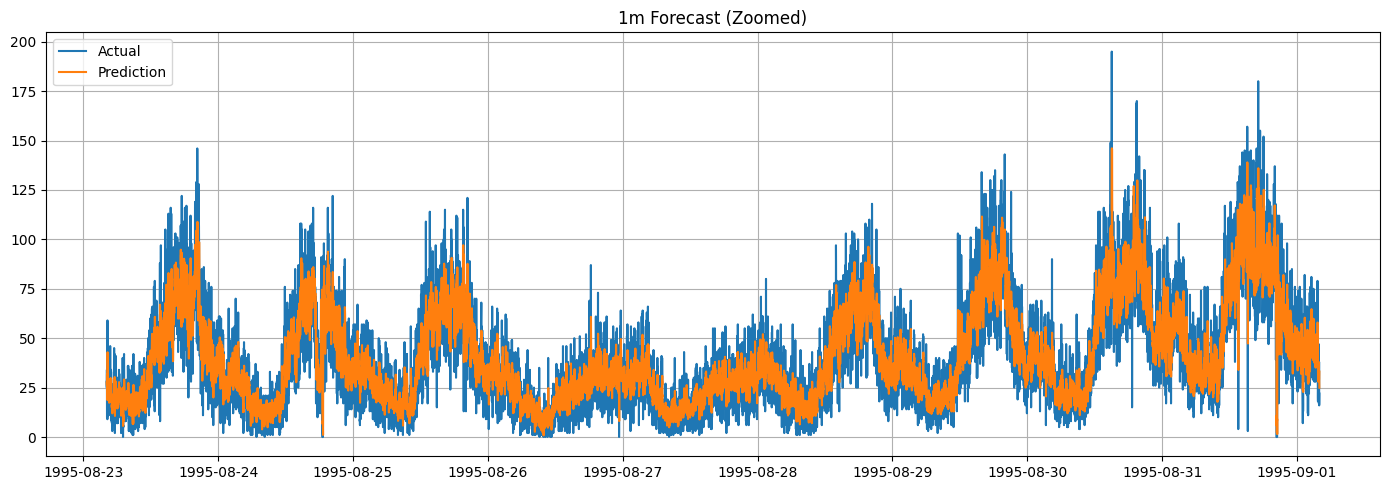

In [27]:
plot_forecast(
    df_plot_1m,
    title="1m Forecast (Zoomed)"
)


### Benchmark 5m

In [28]:
model, metrics_5m, df_plot_5m = run_pipeline(
    train_df=data_train,
    test_df=data_test,
    window="5min"
)

metrics_5m

,value
MSE,2152.292725
MAE,34.825531
RMSE,46.392809
R2,0.857431
MAPE,0.280296


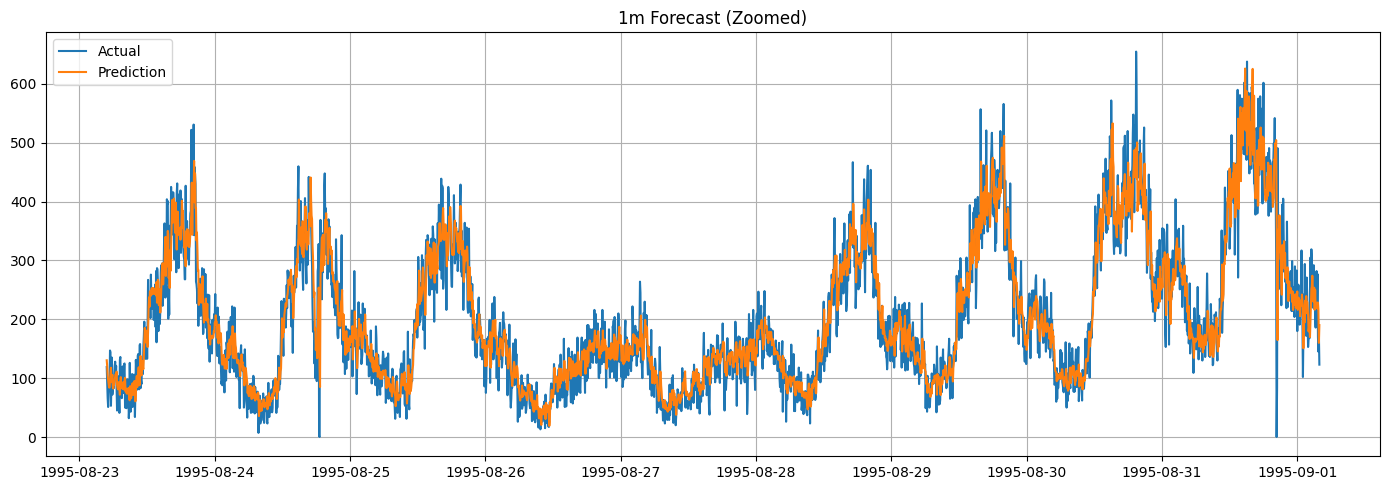

In [29]:
plot_forecast(
    df_plot_5m,
    title="1m Forecast (Zoomed)"
)

### Benchmark 15m

In [30]:
model, metrics_15m, df_plot_15m = run_pipeline(
    train_df=data_train,
    test_df=data_test,
    window="15min"
)

metrics_15m

,value
MSE,14078.789062
MAE,84.311600
RMSE,118.654073
R2,0.889226
MAPE,0.166371


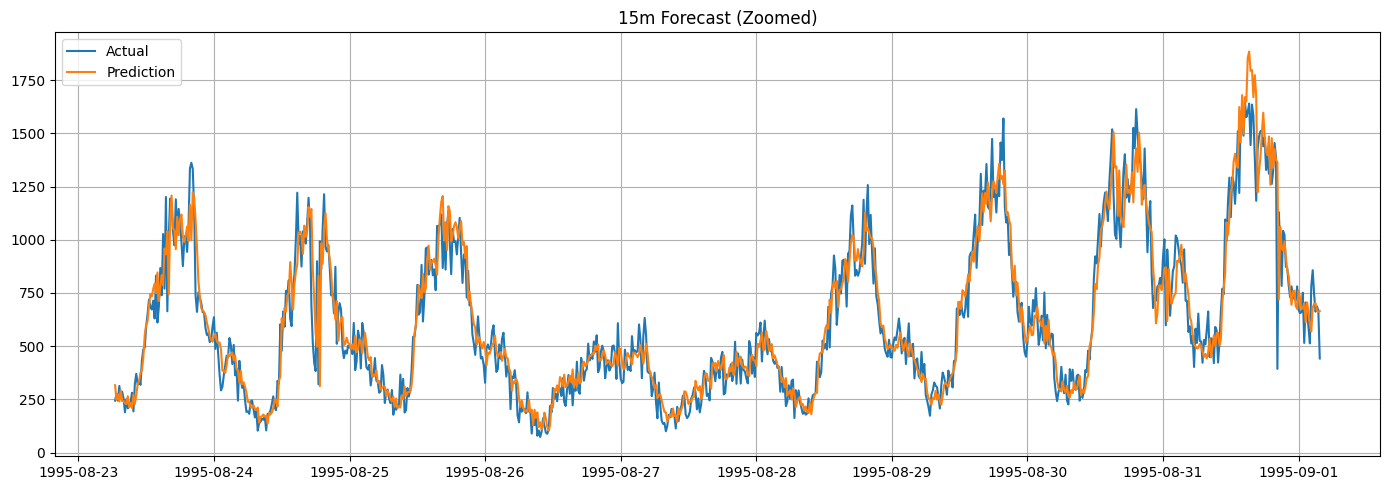

In [31]:
plot_forecast(
    df_plot_15m,
    title="15m Forecast (Zoomed)"
)